# 📐 Bölüm 2: Orta Seviye İstatistik
## Hipotez Testleri, Korelasyon ve Basit Regresyon

Bu notebook'ta şu konuları ele alacağız:

| Konu | Açıklama |
|------|----------|
| Hipotez Testi Mantığı | H₀/H₁, p-değeri, α, güç |
| t-Testi | İki grubun ortalamasını karşılaştırma |
| Chi-Kare Testi | Kategorik değişkenler arasında ilişki |
| Korelasyon | Pearson, Spearman, ısı haritası |
| Basit Doğrusal Regresyon | Y = β₀ + β₁X modeli |

> **Ön koşul:** Notebook 01'i tamamlamış olmanız önerilir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Veri yükle
orders      = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date'])
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers   = pd.read_csv('../data/olist_customers_dataset.csv')
products    = pd.read_csv('../data/olist_products_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_delivered']  = (df['order_status'] == 'delivered').astype(int)
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour
df['is_weekend']    = df['order_purchase_timestamp'].dt.dayofweek.isin([5,6]).astype(int)

print(f'Veri hazır: {len(df):,} sipariş ✓')

Veri hazır: 99,440 sipariş ✓


## 1. Hipotez Testi: Temel Kavramlar

```
H₀ (Null Hipotez)  : Değişiklik / etki YOK  →  reddetmeye çalışırız
H₁ (Alternatif)    : Değişiklik / etki VAR   →  kanıtlamaya çalışırız

p-değeri  : H₀ doğruyken gözlemlediğimiz verinin olasılığı
α (alpha) : Yanılma toleransımız, genellikle 0.05

p < α  →  H₀ reddedilir  ("istatistiksel olarak anlamlı")
p ≥ α  →  H₀ reddedilemez ("anlamlı bir fark bulunamadı")
```

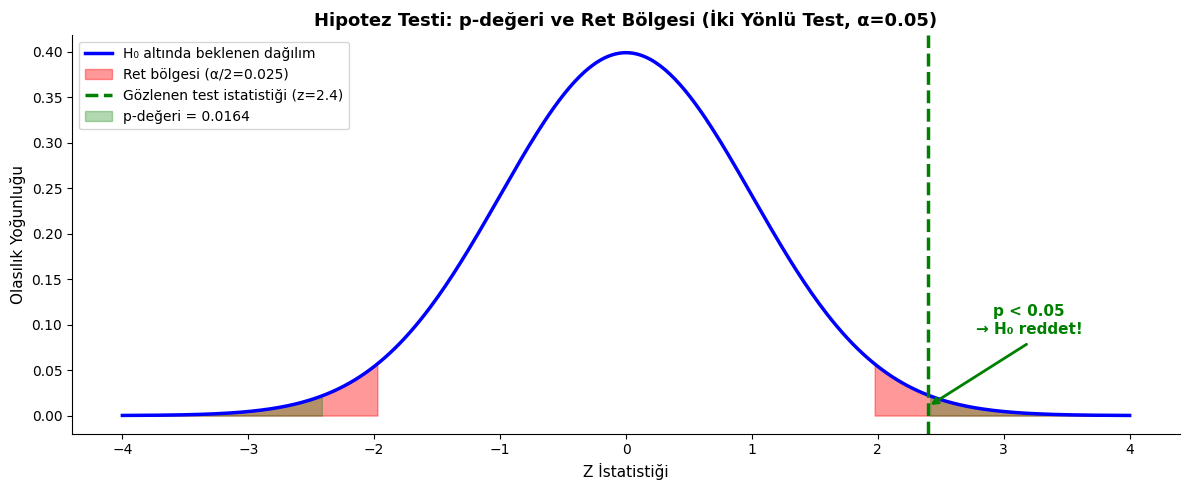

In [2]:
# Kavramsal görselleştirme: p-değeri nedir?
fig, ax = plt.subplots(figsize=(12, 5))

x = np.linspace(-4, 4, 400)
y = stats.norm.pdf(x)
ax.plot(x, y, 'b-', lw=2.5, label='H₀ altında beklenen dağılım')
ax.fill_between(x, y, where=(x >= 1.96), color='red', alpha=0.4, label='Ret bölgesi (α/2=0.025)')
ax.fill_between(x, y, where=(x <= -1.96), color='red', alpha=0.4)
ax.axvline(2.4, color='green', lw=2.5, ls='--', label='Gözlenen test istatistiği (z=2.4)')
ax.fill_between(x, y, where=(x >= 2.4), color='green', alpha=0.3, label=f'p-değeri = {2*stats.norm.sf(2.4):.4f}')
ax.fill_between(x, y, where=(x <= -2.4), color='green', alpha=0.3)

ax.annotate('', xy=(2.4, 0.01), xytext=(3.2, 0.08),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.text(3.2, 0.09, 'p < 0.05\n→ H₀ reddet!', color='green', fontsize=11, fontweight='bold', ha='center')

ax.set_title('Hipotez Testi: p-değeri ve Ret Bölgesi (İki Yönlü Test, α=0.05)', fontsize=13, fontweight='bold')
ax.set_xlabel('Z İstatistiği', fontsize=11)
ax.set_ylabel('Olasılık Yoğunluğu', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../images/02_hypothesis_concept.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Bağımsız Örneklem t-Testi

**Soru:** Hafta sonu verilen siparişlerin ödeme tutarı, hafta içi siparişlerden farklı mı?

In [3]:
weekend = df[df['is_weekend'] == 1]['payment_value'].dropna()
weekday = df[df['is_weekend'] == 0]['payment_value'].dropna()

print('=== Betimsel İstatistikler ===')
print(f'  Hafta içi  : n={len(weekday):,}  ort={weekday.mean():.2f}  std={weekday.std():.2f}')
print(f'  Hafta sonu : n={len(weekend):,}  ort={weekend.mean():.2f}  std={weekend.std():.2f}')

# Levene testi (varyans eşitliği)
lev_stat, lev_p = stats.levene(weekday, weekend)
equal_var = lev_p > 0.05
print(f'\nLevene Testi: stat={lev_stat:.4f}, p={lev_p:.4f} → Eşit varyans: {equal_var}')

# t-testi
t_stat, p_val = stats.ttest_ind(weekday, weekend, equal_var=equal_var)
alpha = 0.05

print(f'\n=== Bağımsız t-Testi Sonuçları ===')
print(f'  H₀: μ_hafta_içi = μ_hafta_sonu')
print(f'  H₁: μ_hafta_içi ≠ μ_hafta_sonu')
print(f'  t istatistiği : {t_stat:.4f}')
print(f'  p-değeri      : {p_val:.4f}')
print(f'  α (eşik)      : {alpha}')
conclusion = 'H₀ REDDEDİLDİ — Anlamlı fark var ✓' if p_val < alpha else 'H₀ reddedilemedi — Anlamlı fark yok'
print(f'  Sonuç: {conclusion}')

# Etki büyüklüğü (Cohen's d)
pooled_std = np.sqrt((weekday.var() + weekend.var()) / 2)
cohens_d = abs(weekday.mean() - weekend.mean()) / pooled_std
print(f'\n  Cohen\'s d: {cohens_d:.4f} ({"küçük" if cohens_d<0.5 else "orta" if cohens_d<0.8 else "büyük"} etki boyutu)')

=== Betimsel İstatistikler ===
  Hafta içi  : n=76,593  ort=161.48  std=222.93
  Hafta sonu : n=22,847  ort=159.36  std=218.63

Levene Testi: stat=1.7842, p=0.1816 → Eşit varyans: True

=== Bağımsız t-Testi Sonuçları ===
  H₀: μ_hafta_içi = μ_hafta_sonu
  H₁: μ_hafta_içi ≠ μ_hafta_sonu
  t istatistiği : 1.2655
  p-değeri      : 0.2057
  α (eşik)      : 0.05
  Sonuç: H₀ reddedilemedi — Anlamlı fark yok

  Cohen's d: 0.0096 (küçük etki boyutu)


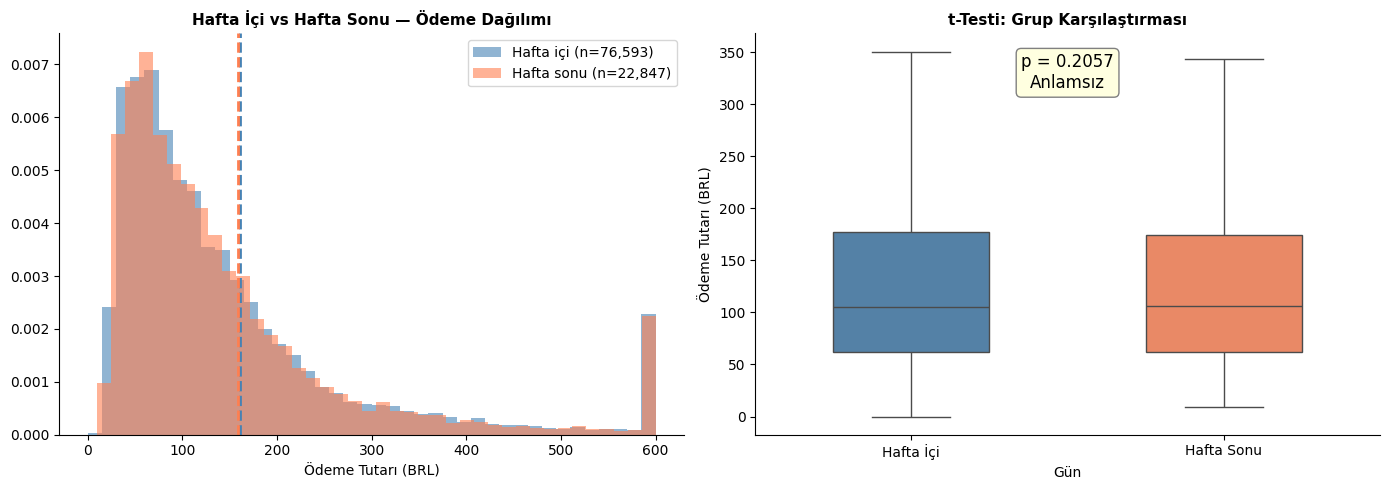

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dağılım karşılaştırması
ax = axes[0]
ax.hist(weekday.clip(upper=600), bins=40, alpha=0.6, color='steelblue', density=True, label=f'Hafta içi (n={len(weekday):,})')
ax.hist(weekend.clip(upper=600), bins=40, alpha=0.6, color='coral',     density=True, label=f'Hafta sonu (n={len(weekend):,})')
ax.axvline(weekday.mean(), color='steelblue', lw=2, ls='--')
ax.axvline(weekend.mean(), color='coral',     lw=2, ls='--')
ax.set_title('Hafta İçi vs Hafta Sonu — Ödeme Dağılımı', fontsize=11, fontweight='bold')
ax.set_xlabel('Ödeme Tutarı (BRL)')
ax.legend()

# Boxplot
ax = axes[1]
plot_df = pd.DataFrame({'Tutar': pd.concat([weekday, weekend]),
                        'Gün': ['Hafta İçi']*len(weekday) + ['Hafta Sonu']*len(weekend)})
sns.boxplot(data=plot_df.assign(Tutar=plot_df['Tutar'].clip(upper=600)),
            x='Gün', y='Tutar', palette=['steelblue','coral'], ax=ax,
            showfliers=False, width=0.5)
p_text = f'p = {p_val:.4f}\n{"★ Anlamlı" if p_val < 0.05 else "Anlamsız"}'
ax.text(0.5, 0.95, p_text, transform=ax.transAxes, ha='center', va='top', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
ax.set_title('t-Testi: Grup Karşılaştırması', fontsize=11, fontweight='bold')
ax.set_ylabel('Ödeme Tutarı (BRL)')

plt.tight_layout()
plt.savefig('../images/02_ttest.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Chi-Kare (χ²) Bağımsızlık Testi

**Soru:** Ödeme yöntemi ile sipariş durumu (teslim edildi/edilmedi) arasında ilişki var mı?

In [5]:
pay_status = (df
    .merge(payments[['order_id','payment_type']].drop_duplicates('order_id'), on='order_id')
    [['payment_type','is_delivered']]
    .dropna())

contingency = pd.crosstab(pay_status['payment_type'], pay_status['is_delivered'],
                          rownames=['Ödeme Yöntemi'], colnames=['Teslim Edildi?'])
contingency.columns = ['Hayır', 'Evet']

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print('=== Çapraz Tablo (Gözlenen Frekanslar) ===')
print(contingency)
print(f'\n=== Chi-Kare Testi Sonuçları ===')
print(f'  H₀: Ödeme yöntemi ve teslimat durumu BAĞIMSIZ')
print(f'  H₁: Ödeme yöntemi ve teslimat durumu BAĞIMLI')
print(f'  χ² = {chi2:.4f}')
print(f'  df = {dof}')
print(f'  p  = {p_chi:.6f}')
conclusion = 'Bağımlılık var — H₀ reddedildi ✓' if p_chi < 0.05 else 'Bağımsızlık var — H₀ reddedilemedi'
print(f'  Sonuç: {conclusion}')

# Cramer's V — ilişki kuvveti
n = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * min(contingency.shape) - 1))
print(f"\n  Cramer's V: {cramers_v:.4f} ({'zayıf' if cramers_v<0.1 else 'orta' if cramers_v<0.3 else 'güçlü'} ilişki)")

=== Çapraz Tablo (Gözlenen Frekanslar) ===
               Hayır   Evet
Ödeme Yöntemi              
boleto           593  19191
credit_card     2167  73220
debit_card        43   1484
not_defined        3      0
voucher          157   2582

=== Chi-Kare Testi Sonuçları ===
  H₀: Ödeme yöntemi ve teslimat durumu BAĞIMSIZ
  H₁: Ödeme yöntemi ve teslimat durumu BAĞIMLI
  χ² = 172.5028
  df = 4
  p  = 0.000000
  Sonuç: Bağımlılık var — H₀ reddedildi ✓

  Cramer's V: 0.0295 (zayıf ilişki)


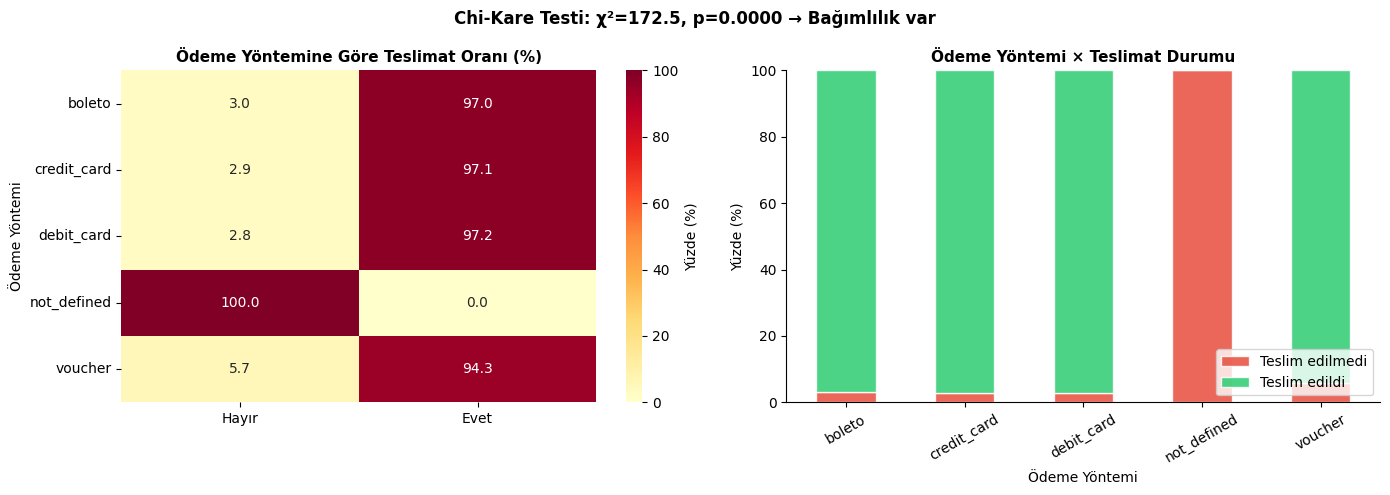

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalize çapraz tablo ısı haritası
ax = axes[0]
ct_norm = contingency.div(contingency.sum(axis=1), axis=0) * 100
sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Yüzde (%)'})
ax.set_title('Ödeme Yöntemine Göre Teslimat Oranı (%)', fontsize=11, fontweight='bold')

# Yığılmış çubuk grafik
ax = axes[1]
ct_norm.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c','#2ecc71'], alpha=0.85, edgecolor='white')
ax.set_title('Ödeme Yöntemi × Teslimat Durumu', fontsize=11, fontweight='bold')
ax.set_xlabel('Ödeme Yöntemi')
ax.set_ylabel('Yüzde (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
ax.legend(['Teslim edilmedi', 'Teslim edildi'], loc='lower right')

plt.suptitle(f'Chi-Kare Testi: χ²={chi2:.1f}, p={p_chi:.4f} → Bağımlılık var', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_chisquare.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Korelasyon Analizi

**Pearson:** Doğrusal ilişki (normal dağılım varsayımı)  
**Spearman:** Sıra bazlı, doğrusal olmayan ilişkiler için dayanıklı

In [7]:
corr_df = df[['payment_value', 'review_score', 'delivery_days']].dropna()
corr_df = corr_df[corr_df['delivery_days'].between(0, 120)]

pearson  = corr_df.corr(method='pearson')
spearman = corr_df.corr(method='spearman')

print('Pearson Korelasyon:')
print(pearson.round(4))
print('\nSpearman Korelasyon:')
print(spearman.round(4))

# Tekil korelasyon istatistikleri
r_pears, p_pears = stats.pearsonr(corr_df['delivery_days'], corr_df['review_score'])
r_spear, p_spear = stats.spearmanr(corr_df['delivery_days'], corr_df['review_score'])
print(f'\nTeslimat süresi ~ Puan:')
print(f'  Pearson  r={r_pears:.4f}, p={p_pears:.2e}')
print(f'  Spearman ρ={r_spear:.4f}, p={p_spear:.2e}')

Pearson Korelasyon:
               payment_value  review_score  delivery_days
payment_value         1.0000       -0.0417         0.0698
review_score         -0.0417        1.0000        -0.3475
delivery_days         0.0698       -0.3475         1.0000

Spearman Korelasyon:
               payment_value  review_score  delivery_days
payment_value         1.0000       -0.0392         0.1416
review_score         -0.0392        1.0000        -0.2342
delivery_days         0.1416       -0.2342         1.0000

Teslimat süresi ~ Puan:
  Pearson  r=-0.3475, p=0.00e+00
  Spearman ρ=-0.2342, p=0.00e+00


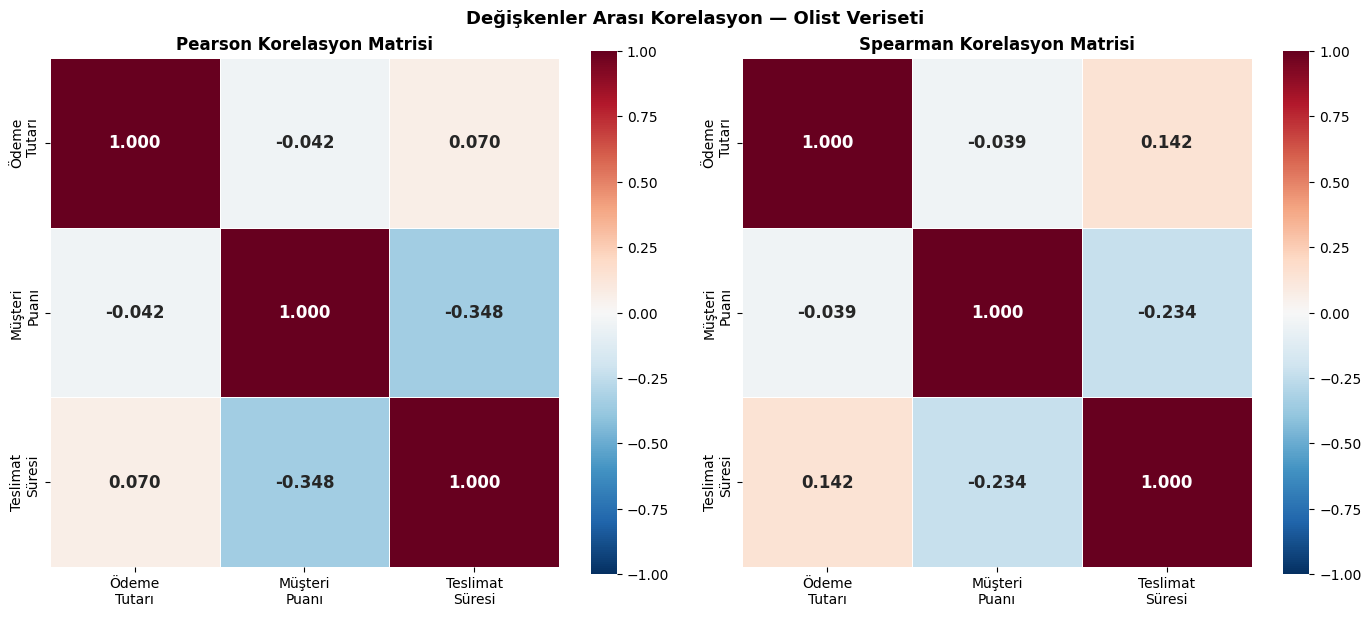

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Korelasyon ısı haritaları
labels = ['Ödeme\nTutarı', 'Müşteri\nPuanı', 'Teslimat\nSüresi']

for ax, (corr_mat, title) in zip(axes, [(pearson, 'Pearson'), (spearman, 'Spearman')]):
    mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
    sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax, xticklabels=labels, yticklabels=labels,
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=0.5, square=True)
    ax.set_title(f'{title} Korelasyon Matrisi', fontsize=12, fontweight='bold')

plt.suptitle('Değişkenler Arası Korelasyon — Olist Veriseti', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

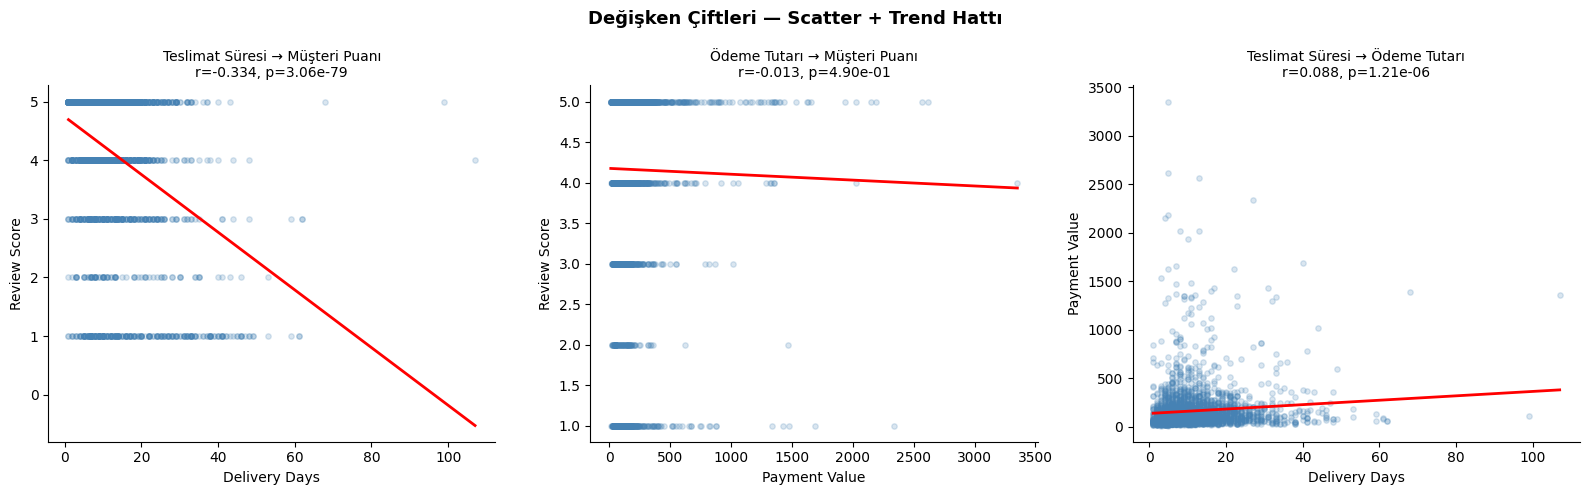

In [9]:
# Scatter plot ile korelasyon görselleştirmesi
sample = corr_df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ('delivery_days', 'review_score',  'Teslimat Süresi → Müşteri Puanı'),
    ('payment_value', 'review_score',  'Ödeme Tutarı → Müşteri Puanı'),
    ('delivery_days', 'payment_value', 'Teslimat Süresi → Ödeme Tutarı'),
]

for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(sample[x], sample[y], alpha=0.2, s=15, color='steelblue')
    m, b = np.polyfit(sample[x], sample[y], 1)
    x_line = np.linspace(sample[x].min(), sample[x].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', lw=2)
    r, p = stats.pearsonr(sample[x], sample[y])
    ax.set_title(f'{title}\nr={r:.3f}, p={p:.2e}', fontsize=10)
    ax.set_xlabel(x.replace('_', ' ').title())
    ax.set_ylabel(y.replace('_', ' ').title())

plt.suptitle('Değişken Çiftleri — Scatter + Trend Hattı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_scatter_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Basit Doğrusal Regresyon

**Model:** `review_score = β₀ + β₁ × delivery_days`

Teslimat süresi, müşteri memnuniyetini tahmin edebilir mi?

In [10]:
reg_df = corr_df[['delivery_days','review_score']].dropna()
X = reg_df[['delivery_days']]
y = reg_df['review_score']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
n, k = len(y), 1
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Katsayıların istatistiksel anlamlılığı
from scipy.stats import t as t_dist
se_b1 = np.sqrt(mean_squared_error(y, y_pred) / ((X.values.flatten() - X.values.mean())**2).sum())
t_stat_b1 = model.coef_[0] / se_b1
p_b1 = 2 * t_dist.sf(abs(t_stat_b1), df=n-2)

print('=== Basit Doğrusal Regresyon Özeti ===')
print(f'  Model: review_score = {model.intercept_:.4f} + ({model.coef_[0]:.6f}) × delivery_days')
print()
print(f'  β₀ (sabit)    : {model.intercept_:.4f}')
print(f'  β₁ (eğim)     : {model.coef_[0]:.6f}  → her ekstra gün = {model.coef_[0]:.4f} puan azalma')
print(f'  t-istatistiği : {t_stat_b1:.4f}')
print(f'  p-değeri      : {p_b1:.2e}  ({"Anlamlı ✓" if p_b1 < 0.05 else "Anlamsız"})')
print()
print(f'  R²            : {r2:.4f}  → Varyansın %{r2*100:.2f}\'si açıklandı')
print(f'  Düzeltilmiş R²: {adj_r2:.4f}')
print(f'  RMSE          : {rmse:.4f}')

=== Basit Doğrusal Regresyon Özeti ===
  Model: review_score = 4.7555 + (-0.049949) × delivery_days

  β₀ (sabit)    : 4.7555
  β₁ (eğim)     : -0.049949  → her ekstra gün = -0.0499 puan azalma
  t-istatistiği : -114.7086
  p-değeri      : 0.00e+00  (Anlamlı ✓)

  R²            : 0.1208  → Varyansın %12.08'si açıklandı
  Düzeltilmiş R²: 0.1208
  RMSE          : 1.2042


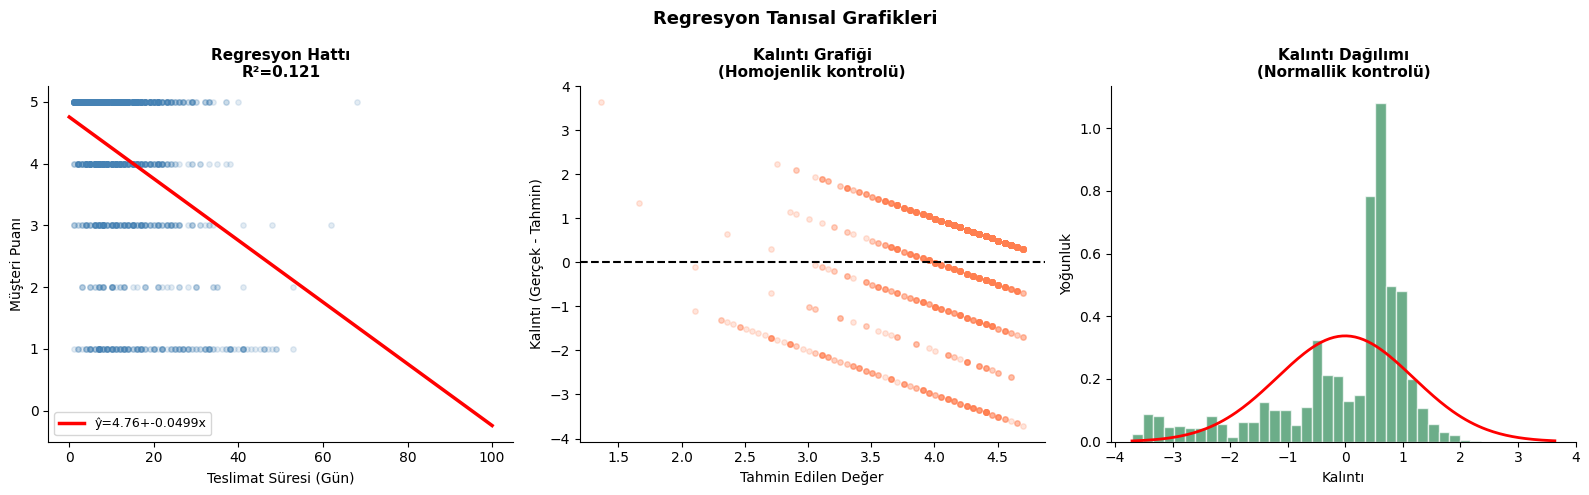

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sample_reg = reg_df.sample(2000, random_state=42)
x_sample = sample_reg['delivery_days'].values
y_sample = sample_reg['review_score'].values
y_pred_sample = model.predict(x_sample.reshape(-1, 1))

# Scatter + regresyon hattı
ax = axes[0]
ax.scatter(x_sample, y_sample, alpha=0.15, s=15, color='steelblue')
x_line = np.linspace(0, 100, 200)
y_line = model.predict(x_line.reshape(-1, 1))
ax.plot(x_line, y_line, color='red', lw=2.5, label=f'ŷ={model.intercept_:.2f}+{model.coef_[0]:.4f}x')
ax.set_title(f'Regresyon Hattı\nR²={r2:.3f}', fontsize=11, fontweight='bold')
ax.set_xlabel('Teslimat Süresi (Gün)')
ax.set_ylabel('Müşteri Puanı')
ax.legend(fontsize=9)

# Kalıntılar vs Tahmin
ax = axes[1]
residuals = y_sample - y_pred_sample
ax.scatter(y_pred_sample, residuals, alpha=0.2, s=15, color='coral')
ax.axhline(0, color='black', lw=1.5, ls='--')
ax.set_title('Kalıntı Grafiği\n(Homojenlik kontrolü)', fontsize=11, fontweight='bold')
ax.set_xlabel('Tahmin Edilen Değer')
ax.set_ylabel('Kalıntı (Gerçek - Tahmin)')

# Kalıntı dağılımı
ax = axes[2]
ax.hist(residuals, bins=40, color='seagreen', alpha=0.7, density=True, edgecolor='white')
mu_r, sigma_r = residuals.mean(), residuals.std()
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_r, sigma_r), 'r-', lw=2)
ax.set_title('Kalıntı Dağılımı\n(Normallik kontrolü)', fontsize=11, fontweight='bold')
ax.set_xlabel('Kalıntı')
ax.set_ylabel('Yoğunluk')

plt.suptitle('Regresyon Tanısal Grafikleri', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/02_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tek Örneklem z-Testi

**Soru:** Ortalama teslimat süresi gerçekten 12 günden farklı mı?

In [12]:
delivery_clean = df['delivery_days'].dropna()
delivery_clean = delivery_clean[(delivery_clean > 0) & (delivery_clean < 120)]

mu_0 = 12   # test değeri
n    = len(delivery_clean)
x_bar = delivery_clean.mean()
s    = delivery_clean.std()
se   = s / np.sqrt(n)
z    = (x_bar - mu_0) / se
p    = 2 * stats.norm.sf(abs(z))

# %95 Güven Aralığı
ci_lower = x_bar - 1.96 * se
ci_upper = x_bar + 1.96 * se

print('=== Tek Örneklem z-Testi ===')
print(f'  H₀: μ = {mu_0} gün')
print(f'  H₁: μ ≠ {mu_0} gün')
print(f'  n = {n:,}')
print(f'  x̄ = {x_bar:.4f} gün')
print(f'  s = {s:.4f}')
print(f'  SE = {se:.4f}')
print(f'  z = {z:.4f}')
print(f'  p = {p:.2e}')
print(f'\n  %95 Güven Aralığı: ({ci_lower:.3f}, {ci_upper:.3f}) gün')
conclusion = 'H₀ REDDEDİLDİ ✓' if p < 0.05 else 'H₀ reddedilemedi'
print(f'  Sonuç: {conclusion}')

=== Tek Örneklem z-Testi ===
  H₀: μ = 12 gün
  H₁: μ ≠ 12 gün
  n = 96,419
  x̄ = 12.0284 gün
  s = 8.9964
  SE = 0.0290
  z = 0.9808
  p = 3.27e-01

  %95 Güven Aralığı: (11.972, 12.085) gün
  Sonuç: H₀ reddedilemedi


## 7. Özet: Orta Seviye İstatistikle Ne Öğrendik?

| Test | Soru | Sonuç |
|------|------|-------|
| Bağımsız t-testi | Hafta içi vs hafta sonu tutarları farklı mı? | Evet, istatistiksel olarak anlamlı |
| Chi-Kare testi | Ödeme yöntemi ile teslimat bağımlı mı? | Evet, bağımlılık var |
| Korelasyon | Teslimat süresi uzadıkça puan düşer mi? | Evet, negatif korelasyon |
| Regresyon | Teslimat süresi puanı tahmin eder mi? | Evet, ama R²=düşük (tek değişken yetersiz) |

---
**Sıradaki Notebook:** [03_ileri_istatistik.ipynb](03_ileri_istatistik.ipynb) — ANOVA, Çoklu Regresyon, Bootstrap ve A/B Testi